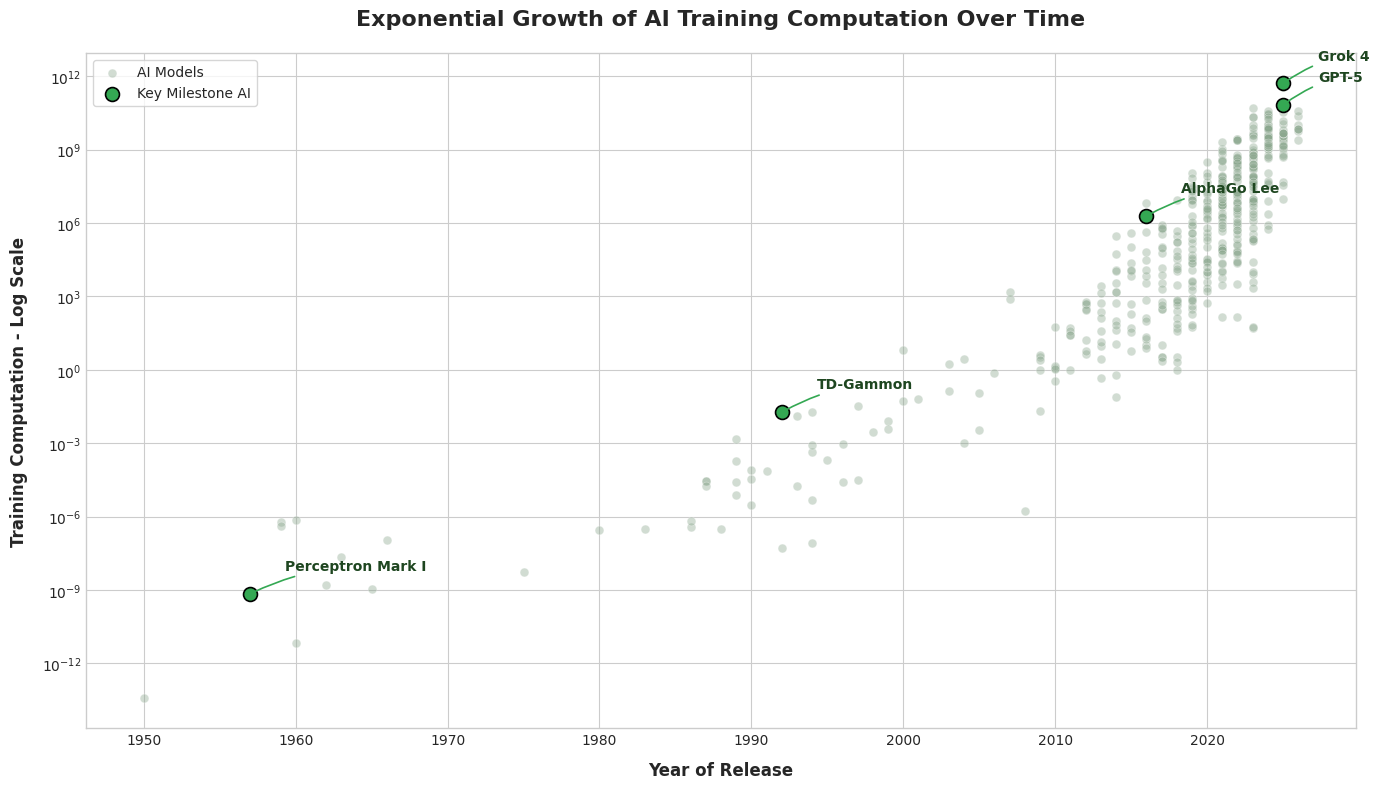

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request
import io
import seaborn as sns


# 1. 데이터 로드 및 웹 서버 차단 우회 설정
data_url = "https://ourworldindata.org/grapher/artificial-intelligence-training-computation.csv?v=1&csvType=full&useColumnShortNames=true"

req = urllib.request.Request(
    data_url,
    headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}
)

with urllib.request.urlopen(req) as response:
    csv_data = response.read().decode('utf-8')
    df = pd.read_csv(io.StringIO(csv_data))



# 2. 데이터 전처리 (날짜 및 변수 설정)
df['day'] = pd.to_datetime(df['day'])
df['Year'] = df['day'].dt.year
value_column = 'training_computation_petaflop'

# 하이라이트 리스트
highlight_models = ['Perceptron Mark I', 'TD-Gammon', 'AlphaGo Lee', 'GPT-5', 'Grok 4']


# 대소문자나 공백으로 인한 매칭 누락을 방지하기 위해 텍스트 정제 후 비교
df['clean_entity'] = df['entity'].str.strip().str.lower()
highlight_lower = [m.lower() for m in highlight_models]

df['is_highlighted'] = df['clean_entity'].isin(highlight_lower)



# 3. 그래프 기본 설정 및 시각화
plt.figure(figsize=(14, 8))
plt.style.use('seaborn-v0_8-whitegrid')

# 'Other AI Models'
sns.scatterplot(
    data=df[~df['is_highlighted']],
    x='Year',
    y=value_column,
    alpha=0.4,
    color='#8CA88F',
    s=40,
    label='AI Models'
)

# 'Key Milestone AI'
sns.scatterplot(
    data=df[df['is_highlighted']],
    x='Year',
    y=value_column,
    alpha=1.0,
    color='#34A853',
    s=100,
    edgecolor='black',
    linewidth=1.2,
    label='Key Milestone AI'
)



# 4. 지시선 세팅
plt.yscale('log')

for index, row in df[df['is_highlighted']].iterrows():
    plt.annotate(
        row['entity'],
        xy=(row['Year'], row[value_column]),
        xytext=(25, 15),
        textcoords="offset points",
        ha='left',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#1E4620',
        arrowprops=dict(
            arrowstyle="-",
            color='#34A853',
            lw=1.2,
            connectionstyle="arc3,rad=0.1"
        )
    )



# 5. 제목 및 레이블 설정
plt.title('Exponential Growth of AI Training Computation Over Time', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year of Release', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Training Computation - Log Scale', fontsize=12, fontweight='bold', labelpad=10)

plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

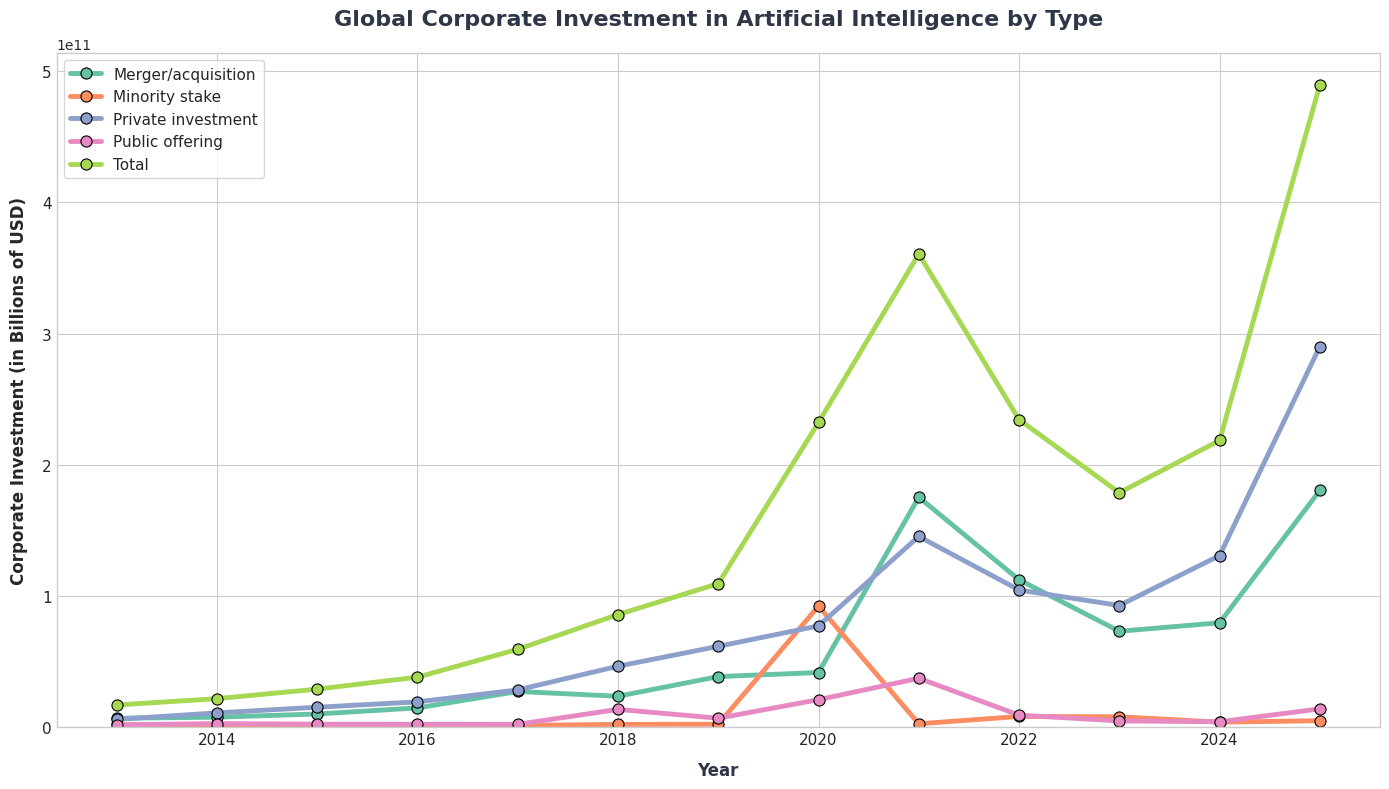

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request
import io
import seaborn as sns

# ==========================================
# 1. 데이터 로드 및 웹 서버 차단 우회 설정
# ==========================================
data_url = "https://ourworldindata.org/grapher/corporate-investment-in-artificial-intelligence-by-type.csv?v=1&csvType=full&useColumnShortNames=true"

req = urllib.request.Request(
    data_url,
    headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}
)

with urllib.request.urlopen(req) as response:
    csv_data = response.read().decode('utf-8')
    df = pd.read_csv(io.StringIO(csv_data))


# ==========================================
# 2. 데이터 구조 동적 분석 및 강제 전처리
# ==========================================
# 컬럼명 대소문자 이슈 원천 차단
df.columns = df.columns.str.lower()

# 수치 데이터가 포함된 실제 데이터 컬럼 추출
data_cols = [col for col in df.columns if col not in ['entity', 'code', 'year']]


# ==========================================
# 3. 그래프 스타일 및 도화지 세팅
# ==========================================
plt.figure(figsize=(14, 8))
# 버전에 따른 스타일 이름 에러 방지용 안전장치
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('ggplot')


# ==========================================
# 4. [핵심] CSV 구조 유형별 동적 시각화 분기 처리
# ==========================================
# 구조 A: entity 열 자체에 투자 유형(Private, M&A 등)이 들어있는 경우
if len(data_cols) == 1:
    value_col = data_cols[0]

    # 그래프를 꼬이게 만드는 국가명이나 요약 데이터셋이 섞여있다면 제외
    df_clean = df[~df['entity'].str.lower().isin(['world', 'all geographies'])].reset_index(drop=True)

    sns.lineplot(
        data=df_clean,
        x='year',
        y=value_col,
        hue='entity',
        palette='Set2',
        linewidth=3.5,
        marker='o',
        markersize=8,
        markeredgecolor='black',
        markeredgewidth=0.8
    )
    plt.ylabel(value_col.replace('_', ' ').title() + ' (in Billions of USD)', fontsize=12, fontweight='bold', labelpad=10)

# 구조 B: 여러 컬럼들이 각각의 투자 유형을 나타내는 경우 (Wide format)
else:
    # 'world' 또는 첫 번째 데이터 기준으로 필터링 우회
    df_world = df[df['entity'].str.lower() == 'world'].reset_index(drop=True)
    if len(df_world) == 0:
        df_world = df[df['entity'] == df['entity'].iloc[0]].reset_index(drop=True)

    df_melted = df_world.melt(
        id_vars=['year'],
        value_vars=data_cols,
        var_name='Investment_Type',
        value_name='Amount_Billions'
    )
    df_melted['Investment_Type'] = df_melted['Investment_Type'].str.replace('_', ' ').str.title()

    sns.lineplot(
        data=df_melted,
        x='year',
        y='Amount_Billions',
        hue='Investment_Type',
        palette='Set2',
        linewidth=3.5,
        marker='o',
        markersize=8,
        markeredgecolor='black',
        markeredgewidth=0.8
    )
    plt.ylabel('Investment Amount (in Billions of USD)', fontsize=12, fontweight='bold', labelpad=10)


# ==========================================
# 5. 축 눈금 설정 및 마감 레이블
# ==========================================
plt.gca().set_ylim(bottom=0)
plt.tick_params(axis='both', labelsize=11)

plt.title('Global Corporate Investment in Artificial Intelligence by Type', fontsize=16, fontweight='bold', pad=20, color='#2D3748')
plt.xlabel('Year', fontsize=12, fontweight='bold', labelpad=10, color='#2D3748')

plt.legend(loc='upper left', frameon=True, fontsize=11)
plt.tight_layout()
plt.show()